# 🧬 Pangenome Analysis Pipeline 
## Part 3: Core & Pangenome Construction using Roary

### 🎯 Objective
With our 50 genomes annotated, we will use **Roary** to construct the pangenome. 
Roary will cluster orthologous genes, split them into the **Core** and **Accessory** genomes, and generate alignments for phylogenetic trees.

### 🗺️ Workflow:
1. Gather all 50 `.gff` files from Prokka into a single folder.
2. Run Roary with MAFFT alignment enabled (`-e --mafft`).

In [1]:
%%bash

# Force bash to activate the conda environment
source ~/miniconda3/bin/activate roary_env

echo "🚀 Starting Roary Pangenome analysis..."
# Run Roary (this might take 10-30 minutes)
roary -e --mafft -p 4 -f roary_output gff_files/*.gff

echo "🎉 Roary has finished successfully!"

🚀 Starting Roary Pangenome analysis...


Use of uninitialized value in require at /home/azureuser/miniconda3/envs/roary_env/lib/site_perl/5.26.2/x86_64-linux-thread-multi/Encode.pm line 61.



Please cite Roary if you use any of the results it produces:
    Andrew J. Page, Carla A. Cummins, Martin Hunt, Vanessa K. Wong, Sandra Reuter, Matthew T. G. Holden, Maria Fookes, Daniel Falush, Jacqueline A. Keane, Julian Parkhill,
	"Roary: Rapid large-scale prokaryote pan genome analysis", Bioinformatics, 2015 Nov 15;31(22):3691-3693
    doi: http://doi.org/10.1093/bioinformatics/btv421
	Pubmed: 26198102



Use of uninitialized value in require at /home/azureuser/miniconda3/envs/roary_env/lib/site_perl/5.26.2/x86_64-linux-thread-multi/Encode.pm line 61.
Use of uninitialized value in require at (eval 975) line 1.


🎉 Roary has finished successfully!


In [2]:
%%bash

# Display the summary statistics nicely
echo "📊 Roary Summary Statistics:"
echo "------------------------------------------------"
cat roary_output/summary_statistics.txt
echo "------------------------------------------------"

# Check the size of the core gene alignment (used for Phylogenetic Tree)
echo "🧬 Core Gene Alignment File Size:"
ls -lh roary_output/core_gene_alignment.aln

📊 Roary Summary Statistics:
------------------------------------------------
Core genes	(99% <= strains <= 100%)	2189
Soft core genes	(95% <= strains < 99%)	380
Shell genes	(15% <= strains < 95%)	1752
Cloud genes	(0% <= strains < 15%)	10086
Total genes	(0% <= strains <= 100%)	14407
------------------------------------------------
🧬 Core Gene Alignment File Size:
-rw-rw-r-- 1 azureuser azureuser 100M Jul 22 19:05 roary_output/core_gene_alignment.aln


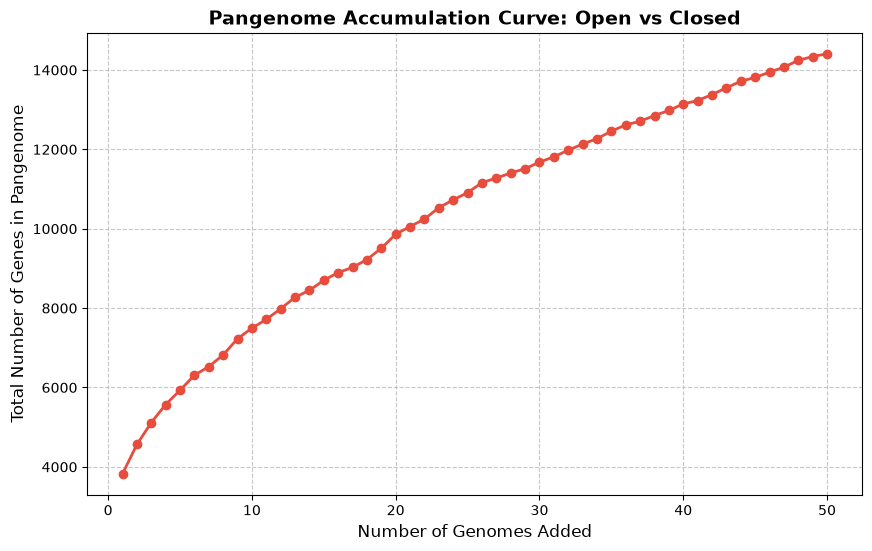

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read the correct file
file_path = 'roary_output/number_of_genes_in_pan_genome.Rtab'
df = pd.read_csv(file_path, sep='\t')

# 2. FIX: Calculate mean across rows for each column (genome count)
mean_pangenome = df.mean(axis=0)

# 3. Plot the corrected curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mean_pangenome) + 1), mean_pangenome.values, marker='o', linestyle='-', color='#e74c3c', linewidth=2)

plt.title('Pangenome Accumulation Curve: Open vs Closed', fontsize=14, fontweight='bold')
plt.xlabel('Number of Genomes Added', fontsize=12)
plt.ylabel('Total Number of Genes in Pangenome', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()